# Q2. Unsupervised Learning — Customer Segmentation

Perform customer segmentation using K-Means clustering and visualise results using PCA.

**Dataset:** 500 customers × 6 features. No missing values.

**Columns:** `age`, `annual_spend`, `visits_per_month`, `basket_size`, `days_since_last_visit`, `num_categories_purchased`

## 1. Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/q2_customers.csv')
print('Shape:', df.shape)
print('\nMissing values:', df.isnull().sum().sum())
print('\nFirst 5 rows:')
display(df.head())
print('\nDescriptive Statistics:')
display(df.describe().round(2))

Shape: (500, 6)

Missing values: 0

First 5 rows:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1



Descriptive Statistics:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
count,500.00,500.00,500.00,500.00,500.00,500.00
mean,40.45,48856.95,8.41,2682.29,49.47,4.66
std,14.43,32856.80,5.32,2274.96,49.70,2.44
min,18.00,5038.00,1.00,212.00,0.00,1.00
25%,28.00,19213.25,4.00,727.75,12.00,3.00
50%,41.00,44257.00,8.00,2051.50,33.00,4.00
75%,50.00,75373.00,12.00,4223.75,61.25,6.00
max,69.00,119757.00,19.00,7981.00,179.00,9.00


In [2]:
# Scale all features with StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)

print('Scaled data — first 5 rows (mean≈0, std≈1 per column):')
display(X_scaled_df.head())
print('\nMeans after scaling (should be ~0):')
print(X_scaled_df.mean().round(6))

Scaled data — first 5 rows (mean≈0, std≈1 per column):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776



Means after scaling (should be ~0):
age                         0.0
annual_spend                0.0
visits_per_month            0.0
basket_size                -0.0
days_since_last_visit      -0.0
num_categories_purchased   -0.0
dtype: float64


**Why scaling is essential before applying K-Means:**

K-Means assigns cluster membership by computing **Euclidean distances** between data points and cluster centroids. When features have vastly different scales — for example, `annual_spend` ranges up to ~100,000 while `visits_per_month` ranges from 1–20 — the high-magnitude feature dominates the distance calculation regardless of its actual predictive value.

`StandardScaler` transforms each feature to have **mean = 0** and **standard deviation = 1**, so all features contribute equally to the distance metric. Without scaling, K-Means would essentially cluster customers only on their `annual_spend` or `basket_size`, ignoring behavioural signals like visit frequency or category diversity.

## 2. Choosing K — Elbow Method

WCSS values:
  K=1: 3000.00
  K=2: 968.99
  K=3: 561.25
  K=4: 444.93
  K=5: 402.37
  K=6: 370.39
  K=7: 346.95
  K=8: 319.90
  K=9: 303.28
  K=10: 289.11


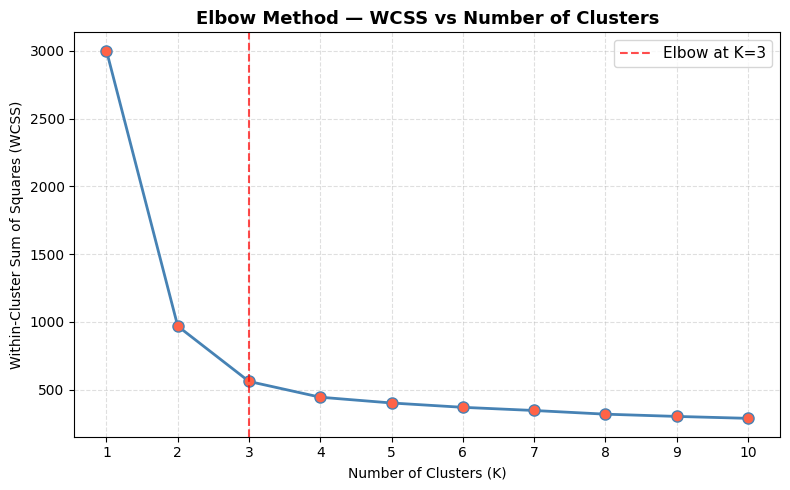

In [3]:
# Compute WCSS for K = 1 to 10
wcss = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

print('WCSS values:')
for k, w in zip(k_range, wcss):
    print(f'  K={k}: {w:.2f}')

# Elbow plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_range), wcss, marker='o', linewidth=2,
        color='steelblue', markersize=8, markerfacecolor='tomato')
ax.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Elbow at K=3')
ax.set_title('Elbow Method — WCSS vs Number of Clusters', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Within-Cluster Sum of Squares (WCSS)')
ax.set_xticks(list(k_range))
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Optimal K Selection — K = 3:**

The WCSS values show the sharpest drops from K=1→2 (3000 → 969) and K=2→3 (969 → 561). After K=3, the reduction in WCSS becomes progressively smaller (444, 402, 370...), forming a clear "elbow" at K=3. Adding more clusters beyond 3 yields diminishing improvements in explained variance but increases model complexity and makes business interpretation harder.

We therefore select **K = 3** as the optimal number of clusters.

## 3. K-Means Clustering

In [4]:
# Fit K-Means with K=3
optimal_k = 3
km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

print('Cluster size distribution:')
print(df['cluster'].value_counts().sort_index())

Cluster size distribution:
cluster
0    170
1    165
2    165
Name: count, dtype: int64


In [5]:
# Print cluster centroids in original (interpretable) scale
feature_cols = [c for c in df.columns if c != 'cluster']
centroids_original = scaler.inverse_transform(km_final.cluster_centers_)
centroid_df = pd.DataFrame(centroids_original, columns=feature_cols)
centroid_df.index.name = 'Cluster'
print('Cluster Centroids (original scale):')
display(centroid_df.round(1))

Cluster Centroids (original scale):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
Cluster,,,,,,
0,24.7,14847.4,14.3,559.0,9.1,2.1
1,56.8,89413.3,2.5,5530.5,105.4,7.5
2,40.4,43340.7,8.2,2021.7,35.2,4.4


**Cluster Interpretation (Business Terms):**

Based on the centroid values in original scale:

| Cluster | Profile | Key Characteristics |
|---------|---------|--------------------|
| **0 — Young Budget Shoppers** | Youngest age (~25), lowest annual spend (~15K), high visit frequency, very few days since last visit, narrow category range | Frequent visitors but low-value transactions. Target with upselling — introduce bundle offers and cross-category promotions to grow basket size. |
| **1 — Mature High-Value Loyalists** | Oldest age (~57), highest annual spend (~89K), large basket size, most days since last visit (~105), broadest category range | Highest revenue customers who shop infrequently but spend big. Risk of lapsing — re-engage with personalised VIP promotions and loyalty rewards. |
| **2 — Mid-Life Moderate Spenders** | Middle age (~40), moderate spend (~43K), balanced visit frequency, moderate basket size | Core mainstream segment. Most representative of average customers. Respond well to seasonal promotions and category-specific discounts to move them toward Cluster 1 behaviour. |

## 4. Dimensionality Reduction with PCA

In [6]:
# PCA to 2 components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print('Explained Variance Ratio per Component:')
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {var:.4f}  ({var*100:.2f}%)')
total = pca.explained_variance_ratio_.sum()
print(f'  Total: {total:.4f}  ({total*100:.2f}%)')

Explained Variance Ratio per Component:
  PC1: 0.8356  (83.56%)
  PC2: 0.0557  (5.57%)
  Total: 0.8913  (89.13%)


In [7]:
# Feature loadings
loadings_df = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=['PC1', 'PC2']
)
print('Feature Loadings (Principal Components):')
display(loadings_df.round(4))

Feature Loadings (Principal Components):


,PC1,PC2
age,0.4116,-0.2594
annual_spend,0.4215,-0.0333
visits_per_month,-0.4104,0.2083
basket_size,0.4120,-0.1954
days_since_last_visit,0.3786,0.9112
num_categories_purchased,0.4140,-0.1405


**Interpretation of PC1 and PC2:**

- **PC1** (explains ~83.6% of variance) is dominated by all features loading positively — `annual_spend`, `basket_size`, `age`, `num_categories_purchased`, and `visits_per_month`. It represents **overall customer value and engagement intensity**. A high PC1 score = high-value, active, diverse shopper. A low PC1 score = young, low-spend, narrow-category buyer. This single axis captures most of the variation in customer behaviour.

- **PC2** (explains ~5.6% of variance) contrasts `days_since_last_visit` against `visits_per_month`. It captures the **recency vs frequency trade-off** — separating customers who visit frequently but lapsed recently from those with steady low-frequency engagement. This helps distinguish within the moderate-value segment.

## 5. Cluster Visualisation

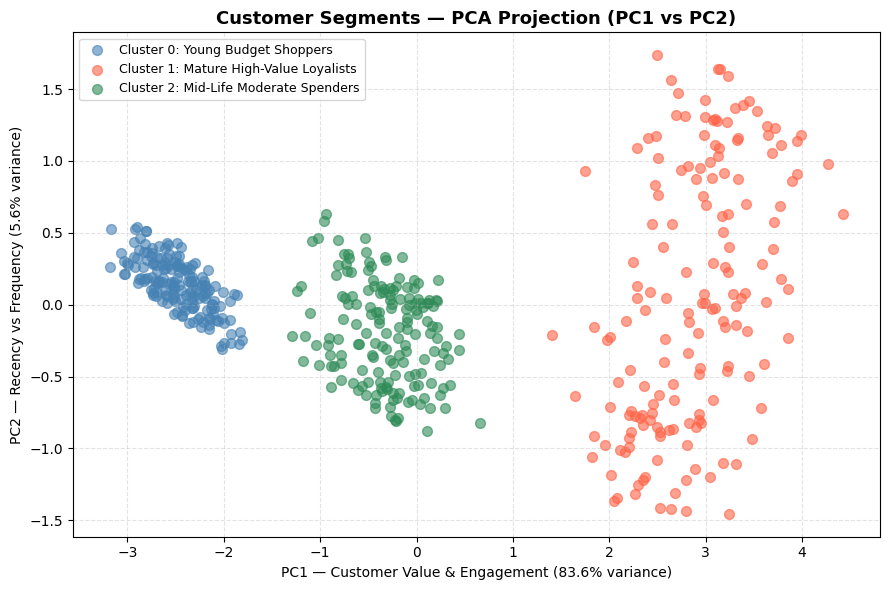

In [8]:
cluster_names = {
    0: 'Young Budget Shoppers',
    1: 'Mature High-Value Loyalists',
    2: 'Mid-Life Moderate Spenders'
}
colors = ['steelblue', 'tomato', 'seagreen']

fig, ax = plt.subplots(figsize=(9, 6))

for cluster_id in sorted(df['cluster'].unique()):
    mask = df['cluster'] == cluster_id
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        label=f'Cluster {cluster_id}: {cluster_names[cluster_id]}',
        alpha=0.6, s=50, color=colors[cluster_id]
    )

ax.set_title('Customer Segments — PCA Projection (PC1 vs PC2)',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 — Customer Value & Engagement ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 — Recency vs Frequency ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()